In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import random
from functools import partial
from typing import Dict, List

from PIL import Image

# For visualization in the notebook
from IPython.display import display, clear_output

# --- Custom Module Imports ---
# Note: Ensure these modules are in your Python path or the same directory.
import sys
sys.path.append("/data1/tct_data/verl-agent/agent_system/environments/env_package/habitat_sim")
from utils.habitat_envs import CreateHabitatEnv
import json

/data1/tct_data/miniconda3/envs/verl-habitat/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-09-26 15:22:40,610	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [ ]:
dataset_name = "ReplicaCAD"
seed = 0
scenes_size = 10
max_scene_instance = 10
max_step_length = 10

env = CreateHabitatEnv(seed, dataset_name, scenes_size, max_scene_instance, max_step_length)
print("Habitat environment created.")

2025-09-26 15:22:43,375	INFO worker.py:1942 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


Habitat environment created.


(TemporaryActor pid=2643763) Exception raised in creation task: The actor died because of an error raised in its creation task, ray::HabitatIoUWorker.__init__() (pid=2643763, ip=10.105.100.175, actor_id=8e210018e1e58575edc5cc7801000000, repr=<utils.habitat_IoU_utils.FunctionActorManager._create_fake_actor_class.<locals>.TemporaryActor object at 0x7f4aefa27d90>)
(TemporaryActor pid=2643763) RuntimeError: The actor with name HabitatIoUWorker failed to import on the worker. This may be because needed library dependencies are not installed in the worker environment:
(TemporaryActor pid=2643763) 
(TemporaryActor pid=2643763) ray::HabitatIoUWorker.__init__() (pid=2643763, ip=10.105.100.175, actor_id=8e210018e1e58575edc5cc7801000000, repr=<utils.habitat_IoU_utils.FunctionActorManager._create_fake_actor_class.<locals>.TemporaryActor object at 0x7f4aefa27d90>)
(TemporaryActor pid=2643763) ModuleNotFoundError: No module named 'utils'
(raylet) [2025-09-26 15:22:53,251 E 2643599 2643625] (raylet) 

In [3]:
task_info = {
        "target_category": "table",
        "instance_id": 5,
        "obj_handle": "/data1/tct_data/habitat/data/replica_cad/configs/objects/frl_apartment_table_02.object_config.json",
        "obj_rotation": [
            -1.0470857603195327e-07,
            -0.9998950362205505,
            8.429370268459024e-08,
            0.014486835338175297
        ],
        "obj_translation": [
            0.43697214126586914,
            0.5924146771430969,
            -0.17916204035282135
        ],
        "bbox_gt": [
            687,
            799,
            356,
            554
        ],
        "bbox_vg": [
            155.4538116455078,
            443.0617980957031,
            578.7733154296875,
            699.2568359375
        ],
        "task_prompt": "Gray couch with pillows",
        "conf_score": 0.8363453149795532,
        "scene_id": "/data1/tct_data/habitat/data/replica_cad/configs/scenes/v3_sc0_staging_13.scene_instance.json",
        "agent_pos": {
            "coords": [
                0.6449050903320312,
                0.15225519239902496,
                2.519923210144043
            ],
            "rotation": 0.9649698462312677
        },
        "task_id": 3
    }

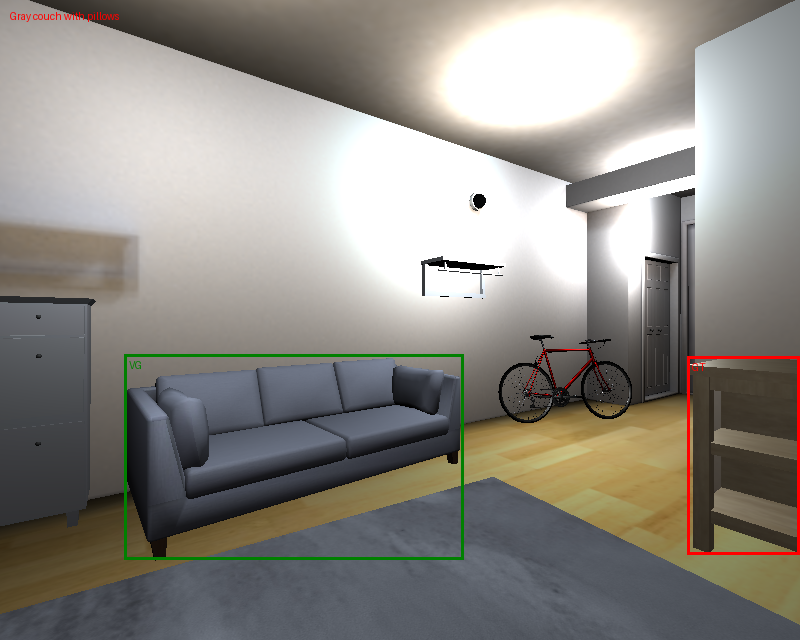

In [4]:
task_img = Image.open("/data1/tct_data/habitat/eval_data/replica_cad_eval_data-test/images/4.png")
display(task_img)

Renderer:

MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its biding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its biding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its biding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its biding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0


 NVIDIA GeForce RTX 4090/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 535.183.01
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


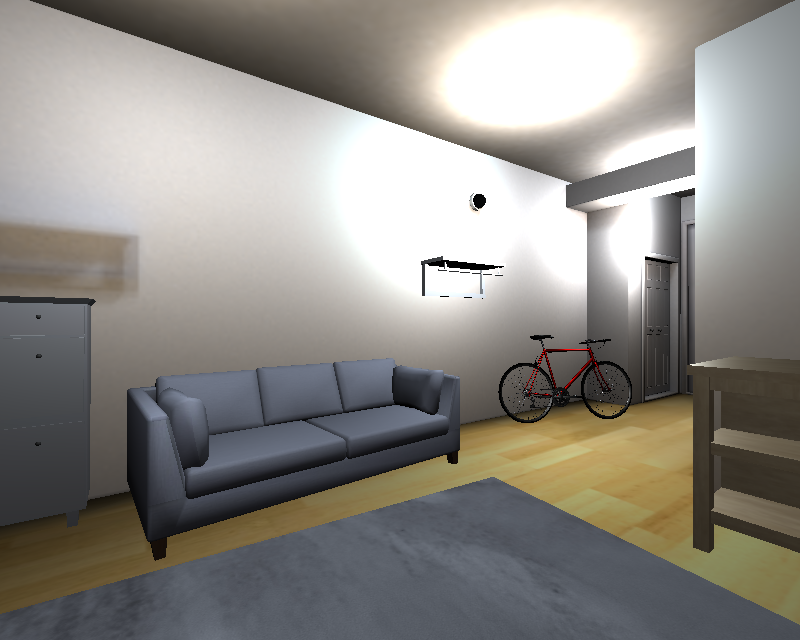

In [5]:
obs, info = env.reset_eval(sync_info=task_info)
display(obs)

In [9]:
from utils.third_party import call_caption_from_pil
xmin, xmax, ymin, ymax = task_info["bbox_gt"] #TODO：task_prompt=="useless"时，重新获取instance_id
caption_response = call_caption_from_pil(obs, xmin, ymin, xmax, ymax, task_info["target_category"])
task_prompt = caption_response["caption"]
print(task_prompt)
print(task_info["task_prompt"])

table near the door
Gray couch with pillows


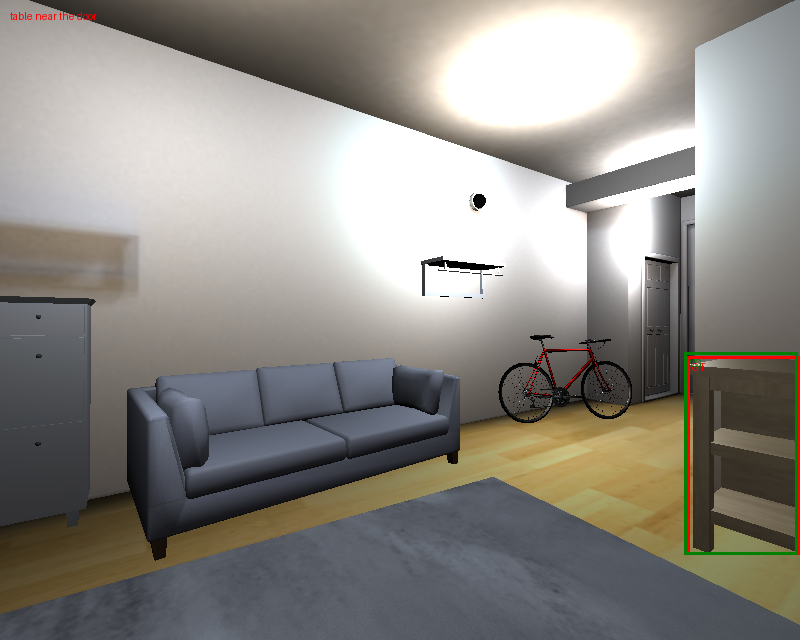

In [10]:
from utils.habitat_utils import draw_bbox_with_text
from utils.third_party import call_grounding_from_pil,reshape_bbox_xxyy

# task_prompt = "wooden table"
grounding_response = call_grounding_from_pil(obs, task_prompt)
bbox_vg = grounding_response["bbox"]

annotation_obs = draw_bbox_with_text(obs, task_info.get("bbox_gt"), text="GT", color="red", title=task_prompt)
annotation_obs = draw_bbox_with_text(annotation_obs, reshape_bbox_xxyy(bbox_vg), text="VG", color="green")
display(annotation_obs)

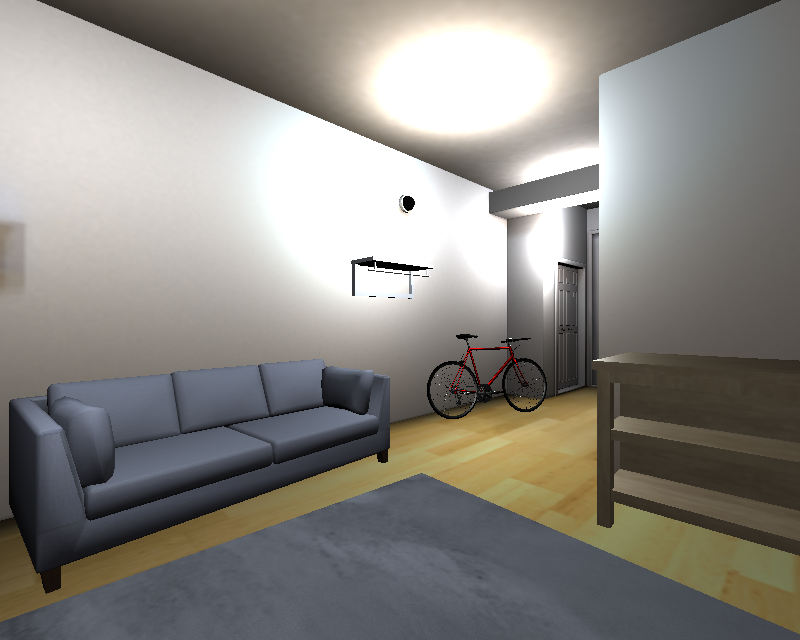

In [8]:
obs_pil, reward, done, info = env.step(2, True)
display(obs_pil)